In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Compo_Diri = '/glade/campaign/univ/upsu0032/Hyperion_ET/composites/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.7.1/'

In [3]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [4]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [5]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [6]:
# Find distance between two points
def Find_Distance(y1, y2, x1, x2):
    Start_Lat = y1 * numpy.pi / 180
    End_Lat = y2 * numpy.pi / 180
    Start_Lon = x1 * numpy.pi / 180
    End_Lon = x2 * numpy.pi / 180
    Lat_Diff = End_Lat - Start_Lat
    Lon_Diff = End_Lon - Start_Lon
    Earth_Rad = 6378
    Distance = 2 * Earth_Rad * numpy.sqrt((numpy.sin(Lat_Diff/2))**2 + \
    numpy.cos(Start_Lat) * numpy.cos(End_Lat) * (numpy.sin(Lon_Diff/2))**2)
    return (Distance)

In [7]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [8]:
# Open files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetC")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetC")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetC")

In [9]:
# Create function to open NetCDF files
def Open_NetCDF_File(File):
    Diri = '/glade/campaign/univ/upsu0032/Hyperion_ET/composites/'
    Compo_File = xr.open_dataset(Diri + File)
    return (Compo_File)

In [10]:
# Open NetCDF files
Control_nc_001 = Open_NetCDF_File('composite_h3_CHEY.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.nc')
Control_nc_002 = Open_NetCDF_File('composite_h3_CHEY.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.002.nc')
Control_nc_003 = Open_NetCDF_File('composite_h3_CHEY.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.004.nc')

In [11]:
# Open NetCDF files
RCP45_nc_001 = Open_NetCDF_File('composite_h3_CHEY.RCP45.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.nc')
RCP45_nc_002 = Open_NetCDF_File('composite_h3_CHEY.RCP45.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.002.nc')
RCP45_nc_003 = Open_NetCDF_File('composite_h3_CHEY.RCP45.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.003.nc')

In [12]:
# Open NetCDF files
RCP85_nc_001 = Open_NetCDF_File('composite_h3_CHEY.RCP85.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.nc')
RCP85_nc_002 = Open_NetCDF_File('composite_h3_CHEY.RCP85.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.003.nc')
RCP85_nc_003 = Open_NetCDF_File('composite_h3_CHEY.RCP85.VR28.NATL.REF.CAM5.4CLM5.0.dtime900.004.nc')

In [13]:
Control_nc_001

<xarray.Dataset>
Dimensions:        (x: 80, y: 80, snapshot: 10562)
Coordinates:
  * x              (x) float64 -11.85 -11.55 -11.25 -10.95 ... 11.25 11.55 11.85
  * y              (y) float64 -11.85 -11.55 -11.25 -10.95 ... 11.25 11.55 11.85
Dimensions without coordinates: snapshot
Data variables: (12/62)
    snap_pathid    (snapshot) int32 ...
    snap_lon       (snapshot) float64 ...
    snap_lat       (snapshot) float64 ...
    snap_time      (snapshot) datetime64[ns] ...
    snap_U850      (snapshot, y, x) float32 ...
    snap_U500      (snapshot, y, x) float32 ...
    ...             ...
    PRECL          (y, x) float32 ...
    FLUT           (y, x) float32 ...
    CLDTOT         (y, x) float32 ...
    TMQ            (y, x) float32 ...
    OMEGA850       (y, x) float32 ...
    OMEGA500       (y, x) float32 ...

In [14]:
# Create dataframe with lat lon time data of the NetCDF files
def Composite_DF(nc, Ensemble, Year_Diff):
    Snap_Time = pandas.Series(nc.snap_time)
    Snap_Lon = pandas.Series(nc.snap_lon)
    Snap_Lat = pandas.Series(nc.snap_lat)
    Snap_PathID = pandas.Series(nc.snap_pathid)
    Index = numpy.arange(0,len(Snap_Time),1)
    Ensembles = []
    New_Time = []
    for i in range(len(Index)):
        Ensembles.append(Ensemble)
        New_Time.append(Update_Year(Snap_Time[i], Year_Diff))
    Compo_DF = pandas.DataFrame({"Index": Index, "Ensemble": Ensembles, \
    "Time": New_Time, "Lon": Snap_Lon, "Lat": Snap_Lat, "PathID": Snap_PathID})
    return (Compo_DF)

In [15]:
# Change year of data
def Update_Year(Orig_Time, Year_Diff):
    Year_Update = Orig_Time.year + Year_Diff
    New_Time = Orig_Time.replace(year=Year_Update)
    return (New_Time)

In [16]:
# Combine composite dataframes
def Combine_Compo_DF(nc_001, nc_002, nc_003, Year_Diffs):
    Compo_DF_001 = Composite_DF(nc_001, 1, Year_Diffs[0])
    Compo_DF_002 = Composite_DF(nc_002, 2, Year_Diffs[1])
    Compo_DF_003 = Composite_DF(nc_003, 3, Year_Diffs[2])
    Compo_DF = pandas.concat([Compo_DF_001, Compo_DF_002, Compo_DF_003]).reset_index(drop=True)
    return (Compo_DF)

In [17]:
Year_Diffs = [[-84,-52,-20], [-68,-36,-4], [32,64,96]]

In [18]:
# Create composite dataframes
Control_Compo = Combine_Compo_DF(Control_nc_001, Control_nc_002, Control_nc_003, Year_Diffs[0])
RCP45_Compo = Combine_Compo_DF(RCP45_nc_001, RCP45_nc_002, RCP45_nc_003, Year_Diffs[1])
RCP85_Compo = Combine_Compo_DF(RCP85_nc_001, RCP85_nc_002, RCP85_nc_003, Year_Diffs[2])

In [19]:
Control_Compo

,Index,Ensemble,Time,Lon,Lat,PathID
0,0,1,1901-08-24 18:00:00,-75.04,21.75,0
1,1,1,1901-08-25 00:00:00,-74.91,22.04,0
2,2,1,1901-08-25 06:00:00,-74.78,22.34,0
3,3,1,1901-08-25 12:00:00,-74.38,23.11,0
4,4,1,1901-08-25 18:00:00,-73.83,24.41,0
...,...,...,...,...,...,...
31218,10497,3,1994-12-15 06:00:00,-41.50,25.75,296
31219,10498,3,1994-12-15 12:00:00,-42.00,26.50,296
31220,10499,3,1994-12-15 18:00:00,-42.75,28.00,296
31221,10500,3,1994-12-16 00:00:00,-43.25,29.25,296


In [20]:
Control_ET

,Code,Name,Orig Code,Ensemble,Trans Type,Peak Time,Peak SLP,Peak Lon,Peak Lat,Trop Peak Time,...,Trop Begin Lon,Trop Begin Lat,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat
0,TC190102,Beatrice,26,1,2,1901-09-03 06:00:00,933.33,-53.61,30.15,1901-09-03 06:00:00,...,-27.73,17.28,1901-09-04 06:00:00,943.55,-50.41,35.84,1901-09-10 06:00:00,978.17,-16.15,55.43
1,TC190106,Ernest,38,1,2,1901-11-22 18:00:00,991.58,-36.06,34.02,1901-11-22 18:00:00,...,-35.72,24.28,1901-11-24 18:00:00,998.89,-42.28,44.18,1901-11-25 00:00:00,998.75,-42.63,48.24
2,TC190203,Kinen,79,1,2,1902-10-13 18:00:00,974.73,-35.58,40.53,1902-10-13 18:00:00,...,-39.96,26.88,1902-10-15 06:00:00,984.17,-21.70,47.01,1902-10-16 00:00:00,999.49,-13.75,44.50
3,TC190302,Mario,100,1,2,1903-02-03 18:00:00,973.36,-28.79,33.46,1903-02-03 18:00:00,...,-63.74,21.55,1903-02-06 12:00:00,991.99,-22.84,47.13,1903-02-07 00:00:00,998.08,-21.25,51.41
4,TC190305,Nicole,120,1,2,1903-08-17 06:00:00,903.29,-66.04,28.17,1903-08-17 06:00:00,...,-48.02,18.24,1903-08-20 00:00:00,952.77,-62.46,38.07,1903-08-21 06:00:00,968.29,-49.44,50.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,TC199204,Daniel,1462,3,2,1992-07-12 06:00:00,986.02,-71.27,38.55,1992-07-11 12:00:00,...,-81.69,34.35,1992-07-11 18:00:00,995.10,-75.34,35.56,1992-07-13 12:00:00,1003.53,-59.03,43.68
214,TC199206,Emily,1475,3,2,1992-09-26 06:00:00,991.29,-76.18,34.46,1992-09-26 06:00:00,...,-74.09,32.66,1992-09-28 12:00:00,998.24,-75.83,37.88,1992-09-29 00:00:00,997.46,-73.94,39.36
215,TC199307,Luca,1514,3,2,1993-08-23 12:00:00,951.47,-71.26,25.86,1993-08-23 12:00:00,...,-50.92,15.44,1993-08-30 06:00:00,983.81,-53.91,48.22,1993-08-30 12:00:00,983.91,-55.38,50.20
216,TC199404,Tess,1568,3,2,1994-08-24 00:00:00,950.53,-61.46,36.80,1994-08-24 00:00:00,...,-54.01,18.37,1994-08-24 12:00:00,952.17,-58.80,38.89,1994-08-27 12:00:00,1002.63,-36.27,46.14


In [21]:
# Create function to find index of selected snapshot
def Find_Snapshot(Compo_DF, Ensemble, Time, Lon, Lat):
# Find possible storms that occur at the same time
    Compo_Storm = Compo_DF[(Compo_DF["Ensemble"] == Ensemble) & (Compo_DF["Time"] == Time)].reset_index(drop=True)
# If no storm found: no index
    if len(Compo_Storm) == 0:
        return (numpy.nan)
# Storms found: find storm closest to storm center
    else:
        Dists = []
        for c in range(len(Compo_Storm)):
            Dists.append(Find_Distance(Lat, Compo_Storm["Lat"][c], Lon, Compo_Storm["Lon"][c]))
        Min_Idx = numpy.array(Dists).argmin()
        Min_Dist = Dists[Min_Idx]
# At most 300km of error in location permitted
        if Min_Dist <= 300:
            return (int(Compo_Storm["Index"][Min_Idx]))
        else:
            return (numpy.nan)

In [22]:
# Create function to find index of tropical peak, ET initiation and ET completion snapshots
def ET_Snapshots_DF(ET_DF, Compo_DF):
    Ensembles = ET_DF["Ensemble"]
    Trop_Peak_Times = ET_DF["Trop Peak Time"]
    Trop_Peak_DF = ET_DF[["Trop Peak SLP", "Trop Peak Lon", "Trop Peak Lat"]].to_numpy().T
    ET_Begin_Times = ET_DF["ET Begin Time"]
    ET_Begin_DF = ET_DF[["ET Begin SLP", "ET Begin Lon", "ET Begin Lat"]].to_numpy().T
    ET_Compl_Times = ET_DF["ET Complete Time"]
    ET_Compl_DF = ET_DF[["ET Complete SLP", "ET Complete Lon", "ET Complete Lat"]].to_numpy().T
#
# Create empty array to store indices
    Index = numpy.zeros((3, len(ET_DF)))
    for i in range(len(ET_DF)):
# Find index of tropical peak points
        Index[0][i] = Find_Snapshot(Compo_DF, Ensembles[i], Trop_Peak_Times[i], Trop_Peak_DF[1][i], Trop_Peak_DF[2][i])
# Find index of ET initiation points
        Index[1][i] = Find_Snapshot(Compo_DF, Ensembles[i], ET_Begin_Times[i], ET_Begin_DF[1][i], ET_Begin_DF[2][i])
# Find index of ET completion points
        Index[2][i] = Find_Snapshot(Compo_DF, Ensembles[i], ET_Compl_Times[i], ET_Compl_DF[1][i], ET_Compl_DF[2][i])
#
# Create new dataframe to store output
    Cols = ["Code", "Name", "Orig Code", "Ensemble", "Trop Peak Time", "Trop Peak SLP", "Trop Peak Lon", "Trop Peak Lat", \
    "ET Begin Time", "ET Begin SLP", "ET Begin Lon", "ET Begin Lat", "ET Complete Time", "ET Complete SLP", "ET Complete Lon", "ET Complete Lat"]
    Index_Cols = ["Trop Peak Index", "ET Begin Index", "ET Complete Index"]
    Snaps_DF = ET_DF[Cols].copy()
    Snaps_DF[Index_Cols] = Index.T
#
# Drop rows with missing index
    Snaps_DF = Snaps_DF.dropna().reset_index(drop=True)
    Snaps_DF[Index_Cols] = Snaps_DF[Index_Cols].astype("Int64")
    return (Snaps_DF)

In [23]:
# Create ET DF with indices of snapshots
Control_Snaps = ET_Snapshots_DF(Control_ET, Control_Compo)
RCP45_Snaps = ET_Snapshots_DF(RCP45_ET, RCP45_Compo)
RCP85_Snaps = ET_Snapshots_DF(RCP85_ET, RCP85_Compo)

In [24]:
Control_Snaps

,Code,Name,Orig Code,Ensemble,Trop Peak Time,Trop Peak SLP,Trop Peak Lon,Trop Peak Lat,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat,Trop Peak Index,ET Begin Index,ET Complete Index
0,TC190102,Beatrice,26,1,1901-09-03 06:00:00,933.33,-53.61,30.15,1901-09-04 06:00:00,943.55,-50.41,35.84,1901-09-10 06:00:00,978.17,-16.15,55.43,74,78,102
1,TC190106,Ernest,38,1,1901-11-22 18:00:00,991.58,-36.06,34.02,1901-11-24 18:00:00,998.89,-42.28,44.18,1901-11-25 00:00:00,998.75,-42.63,48.24,178,186,187
2,TC190203,Kinen,79,1,1902-10-13 18:00:00,974.73,-35.58,40.53,1902-10-15 06:00:00,984.17,-21.70,47.01,1902-10-16 00:00:00,999.49,-13.75,44.50,353,359,362
3,TC190302,Mario,100,1,1903-02-03 18:00:00,973.36,-28.79,33.46,1903-02-06 12:00:00,991.99,-22.84,47.13,1903-02-07 00:00:00,998.08,-21.25,51.41,445,456,458
4,TC190305,Nicole,120,1,1903-08-17 06:00:00,903.29,-66.04,28.17,1903-08-20 00:00:00,952.77,-62.46,38.07,1903-08-21 06:00:00,968.29,-49.44,50.48,543,554,559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,TC199204,Daniel,1462,3,1992-07-11 12:00:00,998.19,-77.70,34.63,1992-07-11 18:00:00,995.10,-75.34,35.56,1992-07-13 12:00:00,1003.53,-59.03,43.68,9633,9634,9641
214,TC199206,Emily,1475,3,1992-09-26 06:00:00,991.29,-76.18,34.46,1992-09-28 12:00:00,998.24,-75.83,37.88,1992-09-29 00:00:00,997.46,-73.94,39.36,9701,9710,9712
215,TC199307,Luca,1514,3,1993-08-23 12:00:00,951.47,-71.26,25.86,1993-08-30 06:00:00,983.81,-53.91,48.22,1993-08-30 12:00:00,983.91,-55.38,50.20,9927,9954,9955
216,TC199404,Tess,1568,3,1994-08-24 00:00:00,950.53,-61.46,36.80,1994-08-24 12:00:00,952.17,-58.80,38.89,1994-08-27 12:00:00,1002.63,-36.27,46.14,10235,10237,10249


In [25]:
RCP45_Snaps

,Code,Name,Orig Code,Ensemble,Trop Peak Time,Trop Peak SLP,Trop Peak Lon,Trop Peak Lat,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat,Trop Peak Index,ET Begin Index,ET Complete Index
0,TC200204,Dawn,76,1,2002-03-14 12:00:00,974.18,-58.07,41.52,2002-03-18 00:00:00,984.01,-45.95,51.83,2002-03-18 06:00:00,987.66,-44.42,52.34,49,63,64
1,TC200209,Flavia,93,1,2002-09-03 18:00:00,916.62,-59.07,23.47,2002-09-07 06:00:00,943.24,-65.14,39.41,2002-09-08 06:00:00,983.00,-57.64,52.78,236,250,254
2,TC200210,Harrison,94,1,2002-09-12 00:00:00,924.42,-67.65,29.01,2002-09-17 06:00:00,952.37,-66.94,36.41,2002-09-20 12:00:00,959.76,-32.08,51.73,287,308,321
3,TC200502,Audrey,196,1,2005-03-01 06:00:00,978.90,-46.25,37.88,2005-03-04 00:00:00,981.00,-32.57,49.83,2005-03-05 18:00:00,996.69,-33.75,47.00,769,780,787
4,TC200601,Elyse,246,1,2006-04-07 18:00:00,960.59,-62.65,40.38,2006-04-09 18:00:00,989.43,-54.36,49.48,2006-04-09 18:00:00,989.43,-54.36,49.48,910,918,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,TC209411,Geoffrey,1357,3,2094-11-05 18:00:00,997.26,-57.01,36.87,2094-11-06 00:00:00,994.31,-55.40,37.56,2094-11-09 12:00:00,970.20,-20.27,49.55,7090,7091,7105
141,TC209501,Hazel,1364,3,2095-01-13 18:00:00,980.73,-58.54,29.78,2095-01-14 00:00:00,978.54,-56.81,31.00,2095-01-15 12:00:00,968.11,-41.18,49.59,7117,7118,7124
142,TC209504,Joshua,1381,3,2095-08-25 00:00:00,924.05,-62.11,24.21,2095-08-28 06:00:00,936.79,-61.82,38.62,2095-08-30 00:00:00,968.57,-52.28,51.88,7195,7208,7215
143,TC209511,Mary,1395,3,2095-11-28 00:00:00,989.15,-51.36,44.42,2095-11-28 06:00:00,987.61,-49.98,47.78,2095-11-29 00:00:00,988.95,-45.15,54.75,7448,7449,7452


In [26]:
RCP85_Snaps

,Code,Name,Orig Code,Ensemble,Trop Peak Time,Trop Peak SLP,Trop Peak Lon,Trop Peak Lat,ET Begin Time,ET Begin SLP,ET Begin Lon,ET Begin Lat,ET Complete Time,ET Complete SLP,ET Complete Lon,ET Complete Lat,Trop Peak Index,ET Begin Index,ET Complete Index
0,TC210203,Beatrice,67,1,2102-03-01 12:00:00,943.01,-45.04,45.78,2102-03-04 06:00:00,968.64,-27.09,43.99,2102-03-07 18:00:00,991.45,-17.00,51.75,27,38,52
1,TC210205,Dawn,80,1,2102-08-28 12:00:00,968.16,-79.09,29.45,2102-09-01 06:00:00,1003.30,-76.85,39.42,2102-09-01 12:00:00,1001.84,-74.73,41.55,106,121,122
2,TC210303,Harrison,124,1,2103-07-26 06:00:00,972.98,-56.11,37.49,2103-07-26 12:00:00,971.89,-53.14,39.28,2103-07-28 00:00:00,992.45,-37.66,46.61,252,253,259
3,TC210305,Janet,130,1,2103-09-08 18:00:00,895.97,-57.85,23.01,2103-09-12 18:00:00,934.13,-60.07,35.72,2103-09-14 18:00:00,962.56,-47.38,49.02,323,339,347
4,TC210306,Kinen,131,1,2103-09-21 00:00:00,987.95,-57.90,27.28,2103-09-22 18:00:00,997.21,-55.88,36.75,2103-09-23 18:00:00,1001.49,-44.60,45.12,388,395,399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,TC219405,Queenie,1430,3,2194-09-19 06:00:00,923.97,-52.90,27.34,2194-09-30 06:00:00,1003.13,-29.92,43.14,2194-10-01 00:00:00,1004.07,-26.48,41.59,5518,5562,5565
152,TC219407,Tiffany,1437,3,2194-11-13 12:00:00,895.04,-85.66,19.61,2194-11-17 12:00:00,920.27,-80.08,21.68,2194-11-20 12:00:00,981.25,-49.30,41.08,5656,5672,5684
153,TC219408,William,1439,3,2194-11-13 06:00:00,945.86,-57.77,33.12,2194-11-17 06:00:00,978.43,-56.90,37.77,2194-11-18 12:00:00,967.20,-29.04,51.12,5717,5733,5738
154,TC219502,Andy,1474,3,2195-09-09 06:00:00,928.44,-61.10,38.09,2195-09-09 12:00:00,926.25,-59.21,40.19,2195-09-11 00:00:00,984.72,-40.68,50.61,5807,5808,5814


In [27]:
# Create function to combine snapshot maps
def Snaps_Combine(Var, Snaps_DF, nc_001, nc_002, nc_003):
    Snap_All = numpy.zeros((len(Snaps_DF),3,80,80))
    nc_Map = {1: nc_001, 2: nc_002, 3: nc_003}
    for n in range(len(Snaps_DF)):
        Code = Snaps_DF["Code"][n]
        nc = nc_Map[Snaps_DF["Ensemble"][n]]
# Find snapshots of tropical peak, ET initiation and ET completion
        Snap_Trop_Peak = Snap_Var(nc, Snaps_DF["Trop Peak Index"][n], Var)
        Snap_ET_Begin = Snap_Var(nc, Snaps_DF["ET Begin Index"][n], Var)
        Snap_ET_Compl = Snap_Var(nc, Snaps_DF["ET Complete Index"][n], Var)
# Store snapshot maps
        Snap_All[n][0] = Snap_Trop_Peak
        Snap_All[n][1] = Snap_ET_Begin
        Snap_All[n][2] = Snap_ET_Compl
# Calculate mean of snapshots
    Composites = numpy.mean(Snap_All, axis=0)
    return (Composites)

In [28]:
# Find snapshot based on variable
def Snap_Var(nc, Index, Var):
    Func_Map = {"850hPa Windspeed": Windspeed_850hPa, "Precip Rate": Precip_Rate, "Precipitable Water": Precip_Water}
    Snap = Func_Map[Var](nc, Index)
    return (Snap)

In [29]:
# Calculate 850hPa windspeed
def Windspeed_850hPa(nc, Index):
    U850 = numpy.array(nc.snap_U850[Index])
    V850 = numpy.array(nc.snap_V850[Index])
    Wind850 = numpy.sqrt(U850 **2 + V850 **2)
    return (Wind850)

In [30]:
# Calculate precipitation rate
def Precip_Rate(nc, Index):
    Precip_ms = numpy.array(nc.snap_PRECT[int(Index)])
    Precip_mmhr = Precip_ms * 3600 * 1000
    return (Precip_mmhr)

In [31]:
# Calculate precipitable water
def Precip_Water(nc, Index):
    H2O = numpy.array(nc.snap_TMQ[int(Index)])
    return (H2O)

In [32]:
Snaps_Combine("850hPa Windspeed", Control_Snaps, Control_nc_001, Control_nc_002, Control_nc_003)

array([[[ 5.00908139,  5.00281213,  5.03702   , ...,  6.68350544,
          6.72079048,  6.68090205],
        [ 4.95273727,  4.90880657,  4.93694211, ...,  6.71420897,
          6.66751564,  6.68074661],
        [ 4.99280225,  5.01226552,  4.96275759, ...,  6.70180768,
          6.6635873 ,  6.63119478],
        ...,
        [ 8.90230586,  8.93963189,  8.8525732 , ...,  9.24042691,
          9.22823242,  9.23485759],
        [ 8.96820317,  8.96281722,  8.94834427, ...,  9.36455607,
          9.39661438,  9.35843922],
        [ 9.05862438,  8.97691103,  8.99130252, ...,  9.49668431,
          9.4527939 ,  9.4901879 ]],

       [[ 5.7680712 ,  5.80310403,  5.87697887, ...,  5.99791202,
          6.02705445,  6.01114475],
        [ 5.90003918,  5.8679656 ,  5.87075983, ...,  6.08080272,
          6.06669455,  6.01906559],
        [ 6.03980046,  5.98510001,  5.97222666, ...,  6.05761436,
          6.07222272,  6.10524758],
        ...,
        [ 8.6426394 ,  8.64476928,  8.73598371, ..., 1

In [33]:
# Create function to plot contour maps
def Contour_Map(Axis, i, j, Snap, x_Snap, y_Snap, Bounds, Colours, Var, Title):
# Add Corrdinate Lines
    Axis.plot([-728,728], [0,0], c='black', linestyle='-', linewidth=0.8)
    Axis.plot([0,0], [-728,728], c='black', linestyle='-', linewidth=0.8)
# Plot contour map
    Axis.contourf(x_Snap, y_Snap, Snap, levels=Bounds, colors=Colours, extend='both')
# Formatting
    if Var == "Precip Rate" or Var == "Precipitable Water":
        Axis.set_xlim(-5,5)
        Axis.set_ylim(-5,5)
        Axis.set_xticks(Create_Bins(-5,5,1))
        Axis.set_yticks(Create_Bins(-5,5,1))
    else:
        Axis.set_xlim(-8,8)
        Axis.set_ylim(-8,8)
        Axis.set_xticks(Create_Bins(-8,8,2))
        Axis.set_yticks(Create_Bins(-8,8,2))
    if i == 2:
        Axis.set_xlabel('Lon Diff From Storm Center', fontsize=12)
    if j == 0:
        Axis.set_ylabel('Lat Diff From Storm Center', fontsize=12)
    Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    Axis.set_title(Title, fontsize=20)
# Letter Labels
    Letter_Label(Axis, i*3+j)

In [34]:
# Plot composites
def Composite_Plots(Var, Snaps, x, y, Time_Labels, Bounds, Colours, Savefig, Figname):
#
# Create figure
    Fig = pyplot.figure(figsize=(16,16))
    Axes = Fig.subplots(3,3, sharex=True, sharey=True)
    Ensembles = ["Control", "RCP4.5", "RCP8.5"]
# Plotting
    for i in range(3):
        for j in range(3):
            Title = str(Ensembles[i] + ': ' + Time_Labels[j])
            Contour_Map(Axes[i][j], i, j, Snaps[i][j], x, y, Bounds, Colours, Var, Title)
#
# Colour bar
    Label = Var + ' (' + Var_Unit(Var) + ')'
    Colour_Bar(Fig, Colours, Bounds, Axes[1], Label)
#
# Save figure
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [35]:
# Plot composites differences
def Composite_Diff_Plots(Var, Snaps, x, y, Time_Labels, Bounds, Colours, Diff_Bounds, Diff_Colours, Savefig, Figname):
#
# Create figure
    Fig = pyplot.figure(figsize=(16,16))
    Axes = Fig.subplots(3,3, sharex=True, sharey=True)
    Ensembles = ["Control", "RCP4.5", "RCP8.5"]
# Plot control
    for j in range(3):
        Title = str(Ensembles[0] + ': ' + Time_Labels[j])
        Contour_Map(Axes[0][j], 0, j, Snaps[0][j], x, y, Bounds, Colours, Var, Title)
# Plot difference between control and RCP
    for j in range(3):
        for i in range(2):
            Snap_Diffs = Snaps[i+1] - Snaps[0]
            Title = str(Ensembles[i+1] + (' - ') + Ensembles[0] + (': Diff at ') + Time_Labels[j])
            Contour_Map(Axes[i+1][j], i+1, j, Snap_Diffs[j], x, y, Diff_Bounds, Diff_Colours, Var, Title)
#
# Colour bar for control
    Label = Var + ' (' + Var_Unit(Var) + ')'
    Colour_Bar(Fig, Axes[0], Colours, Bounds, Label)
#
# Colour bar for difference plots
    Label = (Var + ' Difference (' + Var_Unit(Var) + ')')
    for i in range(2):
        Colour_Bar(Fig, Axes[i+1], Diff_Colours, Diff_Bounds, Label)
#
# Save figure
    Fig.tight_layout()
    if Savefig == True:
        Fig.savefig(Output_Diri+Figname, bbox_inches='tight')

In [36]:
# Colour bar
def Colour_Bar(Fig, Axes, Colours, Bounds, Label):
    C_Map = mcolors.ListedColormap(Colours)
    Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='both')
    Cax = Axes[1].inset_axes([0.02, 0.95, 0.96, 0.02], transform=Axes[1].transAxes)
    Cbar = Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax)
    Cbar.set_label(Label, fontsize=13)
    Cbar.ax.tick_params(labelsize=12)

In [37]:
# Units
def Var_Unit(Var):
    if Var == "850hPa Windspeed" or Var == "200hPa Zonal Wind":
        Unit = "m/s"
    elif Var == "Precip Rate":
        Unit = "mm/hr"
    elif Var == "Precipitable Water":
        Unit = "mm"
    return (Unit)

In [38]:
# Define colours and bounds
# 850hPa windspeed
Windspeed_Colours = ['white', 'cyan', 'lightseagreen', 'limegreen', 'gold', 'darkorange', 'red', 'darkviolet']
Windspeed_Bounds = numpy.array([13,18,25,33,41,50,60])
Windspeed_Diff_Colours = ['darkgreen', 'forestgreen', 'limegreen', 'lawngreen', 'white', \
'gold', 'orange', 'darkorange', 'red']
Windspeed_Diff_Bounds = numpy.array([-4,-3,-2,-1,1,2,3,4])
Windspeed_Line_Bounds = numpy.array([[13],[18],[33]])
#
# Precip rate
Precip_Rate_Colours = ['white', 'cyan', 'deepskyblue', 'dodgerblue', 'lightseagreen', 'limegreen', \
'greenyellow', 'gold', 'darkorange']
Precip_Rate_Bounds = numpy.array([0.2,0.5,1,2,5,10,20,30])
Precip_Rate_Diff_Colours = ['saddlebrown', 'orange', 'gold', 'yellow', 'white', \
'cyan', 'deepskyblue', 'dodgerblue', 'mediumblue']
Precip_Rate_Diff_Bounds = numpy.array([-5,-3,-1,-0.5,0.5,1,3,5])
Precip_Rate_Line_Bounds = numpy.array([[1],[5],[10]])
#
# Precipitable water
Precip_Water_Colours = ['white', 'aquamarine', 'springgreen', 'aqua', 'deepskyblue', 'dodgerblue', 'mediumblue']
Precip_Water_Bounds = numpy.array([30,40,50,60,70,80])
Precip_Water_Diff_Colours = ['saddlebrown', 'darkorange', 'orange', 'gold', 'white', \
'cyan', 'deepskyblue', 'dodgerblue', 'mediumblue']
Precip_Water_Diff_Bounds = numpy.array([-15,-10,-5,-2,2,5,10,15])
Precip_Water_Line_Bounds = numpy.array([[50],[60],[70]])

In [39]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)']
    Axis.text(0.05, 0.05, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

In [40]:
# Time labels
Time_Labels = ["Tropical Peak", "ET Begin", "ET Complete"]

In [41]:
# Calculate mean 850hPa windspeed composites
Var = "850hPa Windspeed"
Control_Wind_850_Compo = Snaps_Combine(Var, Control_Snaps, Control_nc_001, Control_nc_002, Control_nc_003)
RCP45_Wind_850_Compo = Snaps_Combine(Var, RCP45_Snaps, RCP45_nc_001, RCP45_nc_002, RCP45_nc_003)
RCP85_Wind_850_Compo = Snaps_Combine(Var, RCP85_Snaps, RCP85_nc_001, RCP85_nc_002, RCP85_nc_003)

TypeError: float() argument must be a string or a real number, not 'Axes'

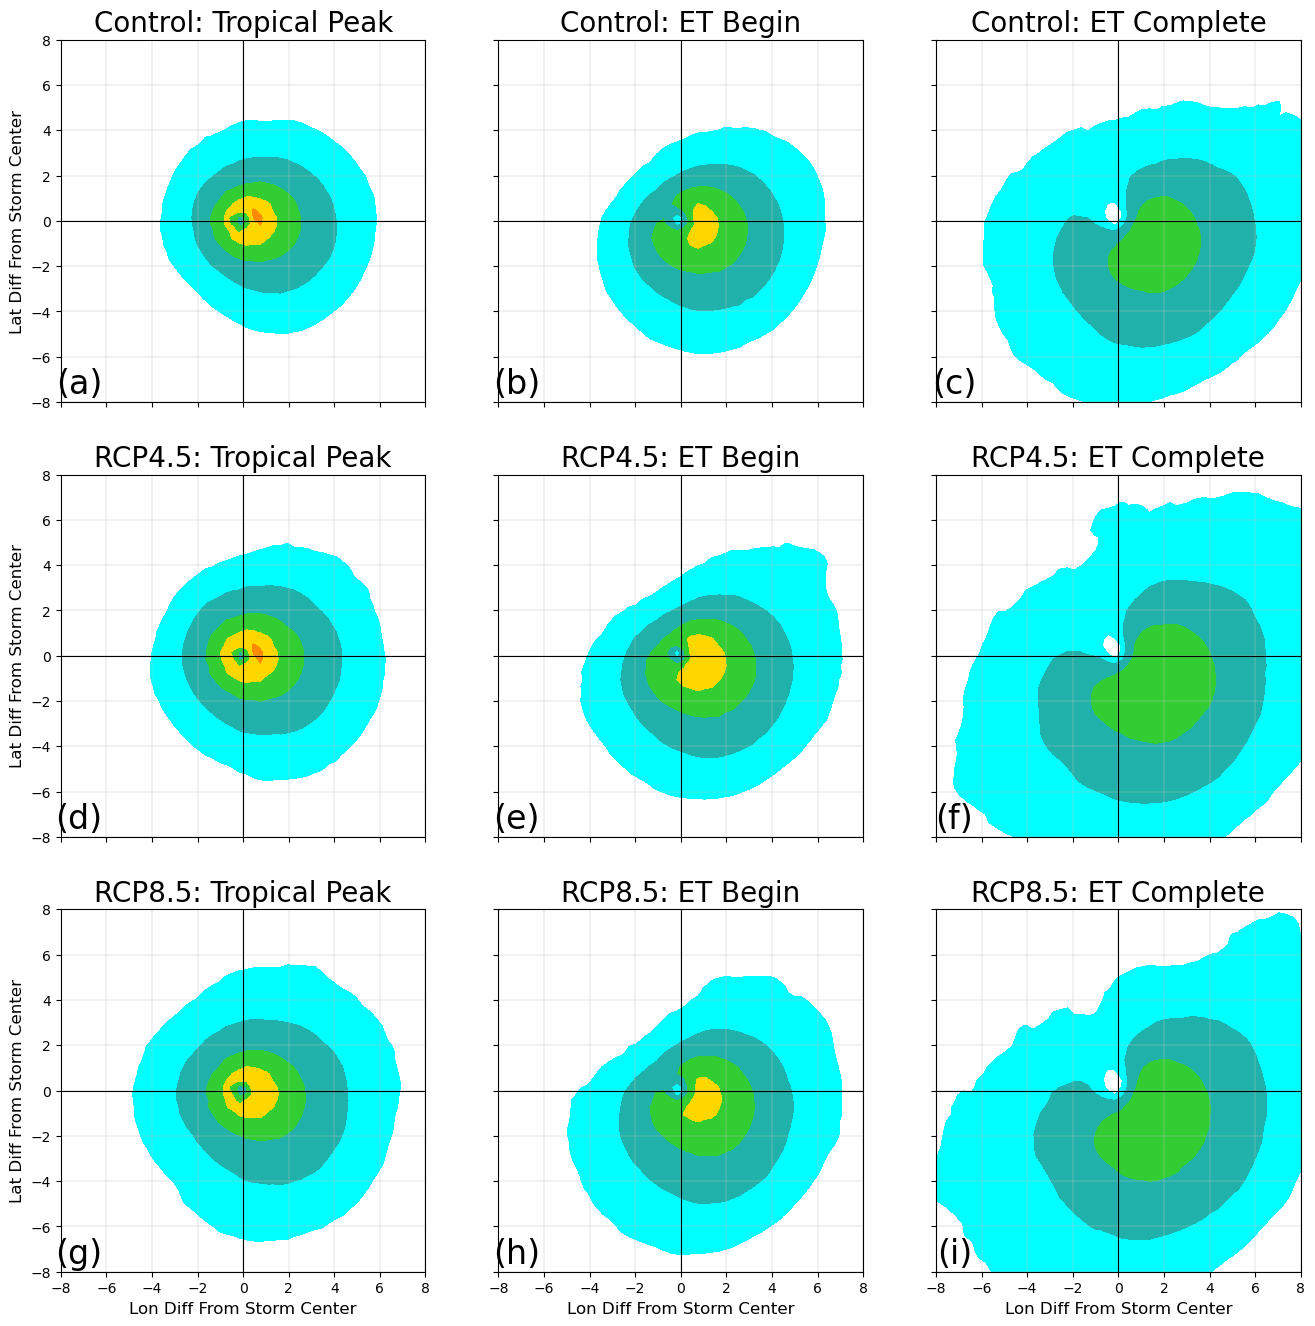

In [42]:
# Plot mean 850hPa windspeed composites
Var = "850hPa Windspeed"
Composites = [Control_Wind_850_Compo, RCP45_Wind_850_Compo, RCP85_Wind_850_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Windspeed_Bounds
Colours = Windspeed_Colours
Savefig = True
Figname = 'Wind_850_Compo.png'
Composite_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Savefig, Figname)

In [ ]:
# Plot mean 850hPa windspeed composites difference
Var = "850hPa Windspeed"
Composites = [Control_Wind_850_Compo, RCP45_Wind_850_Compo, RCP85_Wind_850_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Windspeed_Bounds
Colours = Windspeed_Colours
Diff_Bounds = Windspeed_Diff_Bounds
Diff_Colours = Windspeed_Diff_Colours
Savefig = True
Figname = 'Wind_850_Compo_Diff.png'
Composite_Diff_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Diff_Bounds, Diff_Colours, Savefig, Figname)

In [ ]:
# Calculate mean precip rate composites
Var = "Precip Rate"
Control_Precip_Rate_Compo = Snaps_Combine(Var, Control_Snaps, Control_nc_001, Control_nc_002, Control_nc_003)
RCP45_Precip_Rate_Compo = Snaps_Combine(Var, RCP45_Snaps, RCP45_nc_001, RCP45_nc_002, RCP45_nc_003)
RCP85_Precip_Rate_Compo = Snaps_Combine(Var, RCP85_Snaps, RCP85_nc_001, RCP85_nc_002, RCP85_nc_003)

In [ ]:
# Plot mean precip rate composites
Var = "Precip Rate"
Composites = [Control_Precip_Rate_Compo, RCP45_Precip_Rate_Compo, RCP85_Precip_Rate_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Precip_Rate_Bounds
Colours = Precip_Rate_Colours
Savefig = True
Figname = 'Precip_Rate_Compo.png'
Composite_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Savefig, Figname)

In [ ]:
# Plot mean precip rate composites
Var = "Precip Rate"
Composites = [Control_Precip_Rate_Compo, RCP45_Precip_Rate_Compo, RCP85_Precip_Rate_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Precip_Rate_Bounds
Colours = Precip_Rate_Colours
Diff_Bounds = Precip_Rate_Diff_Bounds
Diff_Colours = Precip_Rate_Diff_Colours
Savefig = True
Figname = 'Precip_Rate_Compo_Diff.png'
Composite_Diff_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Diff_Bounds, Diff_Colours, Savefig, Figname)

In [ ]:
# Calculate mean precipitable water composites
Var = "Precipitable Water"
Control_Precip_Water_Compo = Snaps_Combine(Var, Control_Snaps, Control_nc_001, Control_nc_002, Control_nc_003)
RCP45_Precip_Water_Compo = Snaps_Combine(Var, RCP45_Snaps, RCP45_nc_001, RCP45_nc_002, RCP45_nc_003)
RCP85_Precip_Water_Compo = Snaps_Combine(Var, RCP85_Snaps, RCP85_nc_001, RCP85_nc_002, RCP85_nc_003)

In [ ]:
# Plot mean precipitable water composites
Var = "Precipitable Water"
Composites = [Control_Precip_Water_Compo, RCP45_Precip_Water_Compo, RCP85_Precip_Water_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Precip_Water_Bounds
Colours = Precip_Water_Colours
Savefig = True
Figname = 'Precip_Water_Compo.png'
Composite_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Savefig, Figname)

In [ ]:
# Plot mean precipitable water composites
Var = "Precipitable Water"
Composites = [Control_Precip_Water_Compo, RCP45_Precip_Water_Compo, RCP85_Precip_Water_Compo]
x = Control_nc_001.x
y = Control_nc_001.y
Bounds = Precip_Water_Bounds
Colours = Precip_Water_Colours
Diff_Bounds = Precip_Water_Diff_Bounds
Diff_Colours = Precip_Water_Diff_Colours
Savefig = True
Figname = 'Precip_Water_Compo_Diff.png'
Composite_Diff_Plots(Var, Composites, x, y, Time_Labels, Bounds, Colours, Diff_Bounds, Diff_Colours, Savefig, Figname)